# 2022-C题学习指南（3）：机器学习分类、PCA 与敏感性分析

本章使用第一章输出的预处理数据，回答赛题中“识别未知玻璃类型”和“在玻璃大类内部划分亚类”两类问题。

课程采用一条不重复的数据流程：

> 构造数据集 → 无泄漏标准化 → PCA → 单模型训练与未知样品预测 → 亚类聚类 → 敏感性分析 → 模型评价

共享的数据处理和评价方法只讲解、练习一次；每个建模练习只使用一种分类或聚类模型。主要方法均可在《Practical Statistics for Data Scientists》中找到对应内容。

## Goal

完成本章后，你应该能够：

1. 从预处理表中构造特征矩阵、类型标签和未知样品矩阵；
2. 只使用训练数据拟合标准化参数，避免信息泄漏；
3. 理解 PCA 的方差最大化思想、主成分得分、载荷和解释方差；
4. 把 PCA 得分真正作为逻辑回归的输入；
5. 分别使用 PCA+逻辑回归、KNN、决策树和随机森林预测 A1～A8；
6. 使用 K-means 在高钾或铅钡玻璃内部划分亚型；
7. 对 K-means 初始化和未知样品成分扰动进行敏感性分析；
8. 从混淆矩阵计算指标并评价模型，而不是只报告训练准确率。

## Setup

本章读取：

- `data/processed/2022c-文物采样面.csv`：已知玻璃类型；
- `data/processed/2022c-待鉴别文物.csv`：表单3中的 A1～A8；
- `tests/test_suite_2022c_machine_learning.py`：十一道练习的自动测试。

练习代码中的 `# GRADED FUNCTION` 和函数名不能修改。每个函数末尾已经给出 `return` 语句。

In [1]:
from pathlib import Path
import importlib
import os
import sys

os.environ.setdefault("LOKY_MAX_CPU_COUNT", str(os.cpu_count() or 1))

import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 4)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 110

font_candidates = [
    "Arial Unicode MS", "PingFang SC", "Heiti SC",
    "Microsoft YaHei", "SimHei", "Noto Sans CJK SC",
]
installed_fonts = {font.name for font in font_manager.fontManager.ttflist}
for font_name in font_candidates:
    if font_name in installed_fonts:
        plt.rcParams["font.sans-serif"] = [font_name]
        break
plt.rcParams["axes.unicode_minus"] = False

candidate_dirs = [Path.cwd(), Path.cwd() / "数学建模课程设计案例"]
CASE_DIR = next(
    (path for path in candidate_dirs if (path / "data" / "processed").exists()),
    Path.cwd(),
)
PROCESSED_DIR = CASE_DIR / "data" / "processed"
TESTS_DIR = CASE_DIR / "tests"
NOTEBOOK_FILE = CASE_DIR / "2022-C题学习指南-03-机器学习分类模型.ipynb"
KNOWN_FILE = PROCESSED_DIR / "2022c-文物采样面.csv"
UNKNOWN_FILE = PROCESSED_DIR / "2022c-待鉴别文物.csv"

for required_file in [KNOWN_FILE, UNKNOWN_FILE]:
    if not required_file.exists():
        raise FileNotFoundError(f"缺少 {required_file}，请先完成第一章的数据预处理。")

print("案例目录：", CASE_DIR)
print("已知数据：", KNOWN_FILE)
print("未知数据：", UNKNOWN_FILE)

案例目录： /Users/zhoujason/Desktop/Projects/data-modeling-course-student/数学建模课程设计案例
已知数据： /Users/zhoujason/Desktop/Projects/data-modeling-course-student/数学建模课程设计案例/data/processed/2022c-文物采样面.csv
未知数据： /Users/zhoujason/Desktop/Projects/data-modeling-course-student/数学建模课程设计案例/data/processed/2022c-待鉴别文物.csv


In [2]:
if str(TESTS_DIR) not in sys.path:
    sys.path.insert(0, str(TESTS_DIR))

import base_test_suite
import test_suite_2022c_machine_learning
importlib.reload(base_test_suite)
importlib.reload(test_suite_2022c_machine_learning)

from test_suite_2022c_machine_learning import TestSuite2022CMachineLearning

testsuite = TestSuite2022CMachineLearning()
print("测试套件已加载，共 11 道练习。")

测试套件已加载，共 11 道练习。


## Steps

## 1. 构造分类数据集

### 1.1 一行数据代表什么

机器学习前必须明确数据粒度。本章已知数据的一行表示“一件文物在一种采样面状态下的平均化学成分”，未知数据的一行表示一件待鉴别文物。

我们选择六个有代表性的成分：SiO₂、K₂O、CaO、Al₂O₃、PbO、BaO。标签编码为：

- 高钾 = 0；
- 铅钡 = 1。

输入特征不能包含“类型”，否则模型相当于提前看到答案。已知数据和未知数据还必须使用完全相同的列及顺序。

In [3]:
known_data = pd.read_csv(KNOWN_FILE, dtype={"文物编号": "string"})
unknown_data = pd.read_csv(UNKNOWN_FILE, dtype={"文物编号": "string"})

MODEL_FEATURES = [
    "二氧化硅(SiO2)", "氧化钾(K2O)", "氧化钙(CaO)",
    "氧化铝(Al2O3)", "氧化铅(PbO)", "氧化钡(BaO)",
]
TYPE_TO_CODE = {"高钾": 0, "铅钡": 1}
CODE_TO_TYPE = {0: "高钾", 1: "铅钡"}

display(known_data[["文物编号", "类型", "采样面状态", *MODEL_FEATURES]].head())
display(unknown_data[["文物编号", "表面风化", *MODEL_FEATURES]])

,文物编号,类型,采样面状态,二氧化硅(SiO2),氧化钾(K2O),氧化钙(CaO),氧化铝(Al2O3),氧化铅(PbO),氧化钡(BaO)
0,01,高钾,无风化,69.33,9.99,6.32,3.93,0.00,0.00
1,02,铅钡,风化,36.28,1.05,2.34,5.73,47.43,0.00
2,03,高钾,无风化,74.38,8.78,3.94,4.78,0.83,1.43
3,04,高钾,无风化,65.88,9.67,7.12,6.44,0.00,0.00
4,05,高钾,无风化,61.58,10.95,7.35,7.50,0.00,0.00


,文物编号,表面风化,二氧化硅(SiO2),氧化钾(K2O),氧化钙(CaO),氧化铝(Al2O3),氧化铅(PbO),氧化钡(BaO)
0,A1,无风化,78.45,0.00,6.08,7.23,0.00,0.00
1,A2,风化,37.75,0.00,7.63,2.33,34.30,0.00
2,A3,无风化,31.95,1.36,7.19,2.93,39.58,4.69
3,A4,无风化,35.47,0.79,2.89,7.07,24.28,8.31
4,A5,风化,64.29,0.37,1.64,12.75,12.23,2.16
5,A6,风化,93.17,1.35,0.64,1.52,0.00,0.00
6,A7,风化,90.83,0.98,1.12,5.06,0.00,0.00
7,A8,无风化,51.12,0.23,0.89,2.12,21.24,11.34


### 教师范例：使用四个不同成分构造小型数据集

范例使用 SiO₂、K₂O、PbO、BaO；练习改用六个正式特征。构造时分别保存数值特征、标签和文物编号，便于后续检查预测表。

In [4]:
EXAMPLE_FEATURES = [
    "二氧化硅(SiO2)", "氧化钾(K2O)", "氧化铅(PbO)", "氧化钡(BaO)"
]

X_example = known_data[EXAMPLE_FEATURES].astype(float).reset_index(drop=True)
y_example = known_data["类型"].map(TYPE_TO_CODE).astype(int).reset_index(drop=True)
X_unknown_example = unknown_data[EXAMPLE_FEATURES].astype(float).reset_index(drop=True)
unknown_ids_example = unknown_data["文物编号"].astype("string").reset_index(drop=True)

print("范例已知特征形状：", X_example.shape)
print("范例未知特征形状：", X_unknown_example.shape)
print("类别计数：", y_example.map(CODE_TO_TYPE).value_counts().to_dict())

范例已知特征形状： (61, 4)
范例未知特征形状： (8, 4)
类别计数： {'铅钡': 45, '高钾': 16}


### 练习1：构造已知与未知数据集

补全 `build_glass_datasets`：

1. 从已知数据提取浮点型特征矩阵 `X`；
2. 将高钾、铅钡映射为 0、1，得到 `y`；
3. 保存已知文物编号；
4. 从未知数据提取相同特征顺序的 `X_unknown`；
5. 保存未知文物编号；
6. 重置所有对象的索引后返回。

In [5]:
# UNQ_C1（不要修改下面两行注释，否则测试套件无法收集该函数）
# GRADED FUNCTION: build_glass_datasets
def build_glass_datasets(known_data, unknown_data, feature_columns):
    '''构造玻璃分类的已知特征、标签和未知特征。'''
    # 你的代码从这里开始
    # 第1步：提取已知样本的浮点型特征。
    X = ...

    # 第2步：把高钾映射为0、铅钡映射为1。
    y = ...

    # 第3步：提取已知文物编号。
    known_ids = ...

    # 第4步：以相同的列顺序提取未知样本特征和编号。
    X_unknown = ...
    unknown_ids = ...

    result = {
        "X": X,
        "y": y,
        "known_ids": known_ids,
        "X_unknown": X_unknown,
        "unknown_ids": unknown_ids,
    }
    # 你的代码到这里结束
    return result

In [ ]:
testsuite.test_build_glass_datasets(build_glass_datasets)

## 2. 无泄漏标准化

### 2.1 为什么标准化

KNN、PCA 和 K-means 都依赖距离或方差。如果不同成分的变化范围不同，数值波动大的成分会获得过大的影响。z-score 标准化为：

$$z=\frac{x-\bar{x}_{train}}{s_{train}}.$$

### 2.2 什么是数据泄漏

均值和标准差只能从训练数据学习。如果先对全部数据 `fit_transform` 再划分训练集和测试集，测试信息会提前进入模型。

正确顺序是：

1. `scaler.fit(X_train)`；
2. `scaler.transform(X_train)`；
3. `scaler.transform(X_test_or_unknown)`。

后面的模型通过 Pipeline 自动执行同样规则，因此这里不会为每个模型重复安排标准化练习。

In [7]:
example_scaler = StandardScaler()
example_scaler.fit(X_example)

X_example_scaled = pd.DataFrame(
    example_scaler.transform(X_example),
    index=X_example.index,
    columns=X_example.columns,
)
X_unknown_example_scaled = pd.DataFrame(
    example_scaler.transform(X_unknown_example),
    index=X_unknown_example.index,
    columns=X_unknown_example.columns,
)

display(pd.DataFrame({
    "标准化后训练均值": X_example_scaled.mean(),
    "标准化后未知均值": X_unknown_example_scaled.mean(),
}).round(4))
print("未知数据的均值不必为0，因为scaler没有在未知数据上重新拟合。")

,标准化后训练均值,标准化后未知均值
二氧化硅(SiO2),-0.0,0.4487
氧化钾(K2O),0.0,-0.2932
氧化铅(PbO),0.0,-0.4081
氧化钡(BaO),-0.0,-0.5447


未知数据的均值不必为0，因为scaler没有在未知数据上重新拟合。


### 练习2：只在训练数据上拟合标准化器

补全 `scale_train_and_new`。输出需要恢复成 DataFrame，并保留输入的索引和列名。

In [8]:
# UNQ_C2（不要修改下面两行注释，否则测试套件无法收集该函数）
# GRADED FUNCTION: scale_train_and_new
def scale_train_and_new(X_train, X_new):
    '''只在训练数据上拟合StandardScaler，再转换两组数据。'''
    # 你的代码从这里开始
    # 第1步：创建StandardScaler并只拟合X_train。
    scaler = ...
    ...

    # 第2步：分别转换训练数据和新数据。
    train_values = ...
    new_values = ...

    # 第3步：恢复原索引和列名。
    X_train_scaled = ...
    X_new_scaled = ...

    result = {
        "scaler": scaler,
        "X_train_scaled": X_train_scaled,
        "X_new_scaled": X_new_scaled,
    }
    # 你的代码到这里结束
    return result

In [ ]:
testsuite.test_scale_train_and_new(scale_train_and_new)

## 3. PCA：把多个成分压缩成少数综合变量

### 3.1 核心思想

PCA 寻找原始特征的线性组合：

$$PC_j=Xw_j,$$

使第一主成分具有最大方差，第二主成分在与第一主成分正交的约束下具有最大剩余方差，依次类推。对标准化后的数据协方差矩阵进行特征分解：

$$Cw_j=\lambda_jw_j.$$

- 特征向量 $w_j$ 给出各化学成分的权重，即载荷方向；
- 特征值 $\lambda_j$ 表示该主成分上的方差；
- 主成分得分表示每个文物在新坐标轴上的位置；
- 解释方差比例为 $\lambda_j/\sum_k\lambda_k$。

PCA 的基本假设是“大方差方向包含更多有用信息”。它是无监督降维，不使用玻璃类型标签，因此不能保证主成分一定最有利于分类。

### 3.2 为什么先标准化

化学成分虽然同为百分含量，但不同成分的波动范围差别明显。标准化后执行 PCA，相当于避免高方差成分仅因数值范围大而支配主成分。

,解释方差比例
PC1,0.6357
PC2,0.1878
PC3,0.1668


,PC1,PC2,PC3
二氧化硅(SiO2),0.568,-0.400,0.254
氧化钾(K2O),0.411,0.824,-0.295
氧化铅(PbO),-0.547,-0.117,-0.566
氧化钡(BaO),-0.458,0.384,0.727


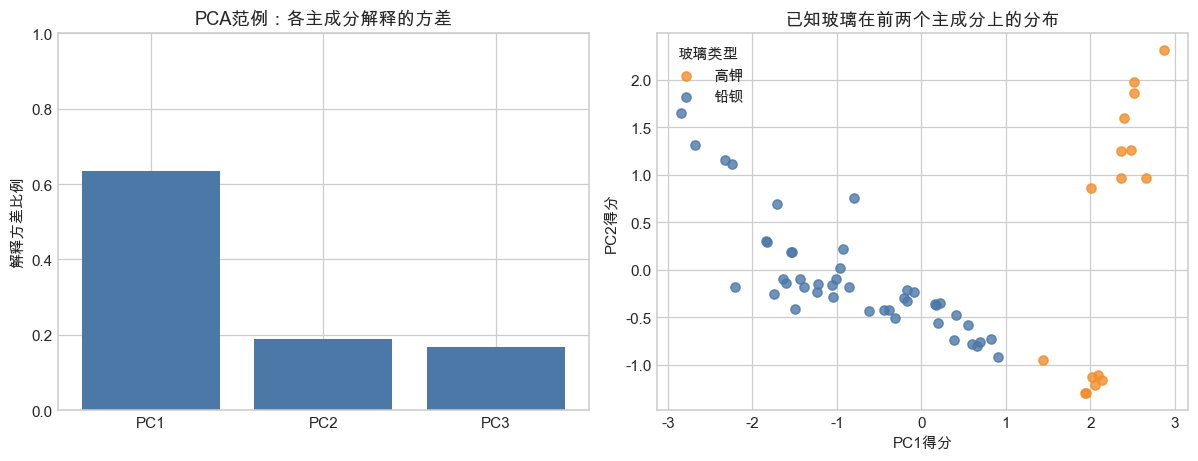

In [10]:
example_pca = PCA(n_components=3, svd_solver="full")
example_pca_scores = example_pca.fit_transform(X_example_scaled)
example_pc_names = ["PC1", "PC2", "PC3"]

example_explained = pd.Series(
    example_pca.explained_variance_ratio_,
    index=example_pc_names,
    name="解释方差比例",
)
example_loadings = pd.DataFrame(
    example_pca.components_.T,
    index=EXAMPLE_FEATURES,
    columns=example_pc_names,
)

display(example_explained.to_frame().round(4))
display(example_loadings.round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
axes[0].bar(example_pc_names, example_explained, color="#4C78A8")
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("解释方差比例")
axes[0].set_title("PCA范例：各主成分解释的方差")

for code_value, type_name, color in [
    (0, "高钾", "#F28E2B"),
    (1, "铅钡", "#4C78A8"),
]:
    mask = y_example.to_numpy() == code_value
    axes[1].scatter(
        example_pca_scores[mask, 0], example_pca_scores[mask, 1],
        color=color, label=type_name, alpha=0.8,
    )
axes[1].set_xlabel("PC1得分")
axes[1].set_ylabel("PC2得分")
axes[1].set_title("已知玻璃在前两个主成分上的分布")
axes[1].legend(title="玻璃类型")
plt.tight_layout()
plt.show()

### 练习3：完成标准化 PCA

补全 `fit_pca_analysis`：函数内部先标准化，再拟合 PCA，并返回：

- 每个样本的 PC 得分；
- 各 PC 的解释方差比例；
- 原始成分对各 PC 的载荷。

练习使用六个成分和三个主成分，与范例不同。

In [11]:
# UNQ_C3（不要修改下面两行注释，否则测试套件无法收集该函数）
# GRADED FUNCTION: fit_pca_analysis
def fit_pca_analysis(X, n_components=3):
    '''对特征进行标准化PCA，并返回得分、解释方差和载荷。'''
    # 你的代码从这里开始
    # 第1步：拟合StandardScaler并转换X。
    scaler = ...
    scaled_values = ...

    # 第2步：用完整SVD拟合指定数量的主成分。
    pca = ...
    score_values = ...

    # 第3步：构造PC1、PC2……列名。
    pc_names = ...

    # 第4步：整理得分、解释方差比例和载荷。
    scores = ...
    explained_variance_ratio = ...
    loadings = ...

    result = {
        "scaler": scaler,
        "pca": pca,
        "scores": scores,
        "explained_variance_ratio": explained_variance_ratio,
        "loadings": loadings,
    }
    # 你的代码到这里结束
    return result

In [ ]:
testsuite.test_fit_pca_analysis(fit_pca_analysis)

## 4. PCA 得分进入逻辑回归

### 4.1 为什么要把 PCA 和分类模型连接起来

只画 PCA 散点图并没有真正建立未知样品分类模型。这里将流程写成：

$$X\rightarrow 标准化\rightarrow PCA得分\rightarrow 逻辑回归\rightarrow 类型概率.$$

逻辑回归在 PC1、PC2、PC3 上学习分类边界，而不是直接使用六个原始成分。Pipeline 保证在模型评价时，每次只用当前训练集拟合 scaler 和 PCA，防止泄漏。

逻辑回归模型为：

$$P(Y=1\mid PC)=\frac{1}{1+e^{-(\beta_0+\beta_1PC_1+\cdots)}}.$$

本章类别 1 是铅钡，因此输出概率表示铅钡概率。参数 `C` 越小，正则化越强。

In [13]:
example_pca_logistic = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2, svd_solver="full")),
    ("classifier", LogisticRegression(
        C=0.5, max_iter=1500, solver="liblinear", random_state=7
    )),
])
example_pca_logistic.fit(X_example, y_example)

example_unknown_prob = example_pca_logistic.predict_proba(X_unknown_example)[:, 1]
example_unknown_pred = example_pca_logistic.predict(X_unknown_example)
example_unknown_pc = example_pca_logistic.named_steps["pca"].transform(
    example_pca_logistic.named_steps["scaler"].transform(X_unknown_example)
)

display(pd.DataFrame({
    "文物编号": unknown_ids_example,
    "PC1": example_unknown_pc[:, 0],
    "PC2": example_unknown_pc[:, 1],
    "铅钡概率": example_unknown_prob,
    "预测类型": pd.Series(example_unknown_pred).map(CODE_TO_TYPE),
}).round(4))

,文物编号,PC1,PC2,铅钡概率,预测类型
0,A1,1.6078,-1.0661,0.3388,高钾
1,A2,-0.3256,-0.6041,0.9055,铅钡
2,A3,-0.7144,-0.0354,0.9321,铅钡
3,A4,-0.4490,0.0370,0.8958,铅钡
4,A5,0.8519,-0.7303,0.5990,铅钡
5,A6,2.0988,-1.0147,0.1834,高钾
6,A7,2.0039,-1.0567,0.2110,高钾
7,A8,-0.2176,-0.1891,0.8680,铅钡


### 练习4：训练 PCA+逻辑回归并预测未知文物

补全 `predict_unknown_pca_logistic`。这里仍然只有一个分类器——逻辑回归；PCA 是它前面的降维步骤。

练习使用六个原始成分、三个主成分和不同的 `C`。

In [14]:
# UNQ_C4（不要修改下面两行注释，否则测试套件无法收集该函数）
# GRADED FUNCTION: predict_unknown_pca_logistic
def predict_unknown_pca_logistic(
    X, y, X_unknown, unknown_ids, n_components=3, C=1.0,
):
    '''用标准化、PCA和逻辑回归预测未知玻璃类型。'''
    # 你的代码从这里开始
    # 第1步：建立StandardScaler、PCA、LogisticRegression流水线。
    model = ...

    # 第2步：在全部已知样本上拟合。
    ...

    # 第3步：预测未知类型和铅钡概率。
    predictions = ...
    probabilities = ...

    # 第4步：显式取得未知样品的PCA得分，证明分类器使用了PCA结果。
    unknown_scaled = ...
    unknown_pca_scores = ...

    # 第5步：整理中文预测表。
    prediction_table = ...

    result = {
        "model": model,
        "predictions": predictions,
        "probabilities": probabilities,
        "unknown_pca_scores": unknown_pca_scores,
        "prediction_table": prediction_table,
    }
    # 你的代码到这里结束
    return result

In [ ]:
testsuite.test_predict_unknown_pca_logistic(predict_unknown_pca_logistic)

## 5. K 近邻（KNN）

KNN 找到与未知样品欧氏距离最近的 K 个训练样品，并以多数类别投票。K 太小容易追随噪声，K 太大会过度平滑。距离模型必须标准化，因此 Pipeline 复用第 2 节的规则，不再重复标准化练习。

欧氏距离为：

$$d(\mathbf{x},\mathbf{u})=\sqrt{\sum_j(x_j-u_j)^2}.$$

In [16]:
example_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", KNeighborsClassifier(n_neighbors=3)),
]).fit(X_example, y_example)

display(pd.DataFrame({
    "文物编号": unknown_ids_example,
    "预测类型": pd.Series(example_knn.predict(X_unknown_example)).map(CODE_TO_TYPE),
}))

,文物编号,预测类型
0,A1,高钾
1,A2,铅钡
2,A3,铅钡
3,A4,铅钡
4,A5,铅钡
5,A6,高钾
6,A7,高钾
7,A8,铅钡


### 练习5：用 KNN 预测未知玻璃

建立 `StandardScaler + KNeighborsClassifier`，使用 `n_neighbors=5` 完成预测。

In [17]:
# UNQ_C5（不要修改下面两行注释，否则测试套件无法收集该函数）
# GRADED FUNCTION: predict_unknown_knn
def predict_unknown_knn(X, y, X_unknown, unknown_ids, n_neighbors=5):
    '''训练KNN并预测未知玻璃类型。'''
    # 你的代码从这里开始
    # 第1步：建立标准化与KNN流水线。
    model = ...

    # 第2步：拟合并预测。
    ...
    predictions = ...

    # 第3步：整理结果表。
    prediction_table = ...

    result = {
        "model": model,
        "predictions": predictions,
        "prediction_table": prediction_table,
    }
    # 你的代码到这里结束
    return result

In [ ]:
testsuite.test_predict_unknown_knn(predict_unknown_knn)

## 6. 决策树

决策树通过“成分是否小于某个阈值”的规则递归划分样本。二分类节点的 Gini 不纯度为：

$$Gini=1-\sum_kp_k^2.$$

每一步选择能使子节点加权不纯度下降最多的特征和阈值。完全生长的树容易记住噪声，因此用 `max_depth` 和 `min_samples_leaf` 控制复杂度。树只比较阈值，不需要标准化。

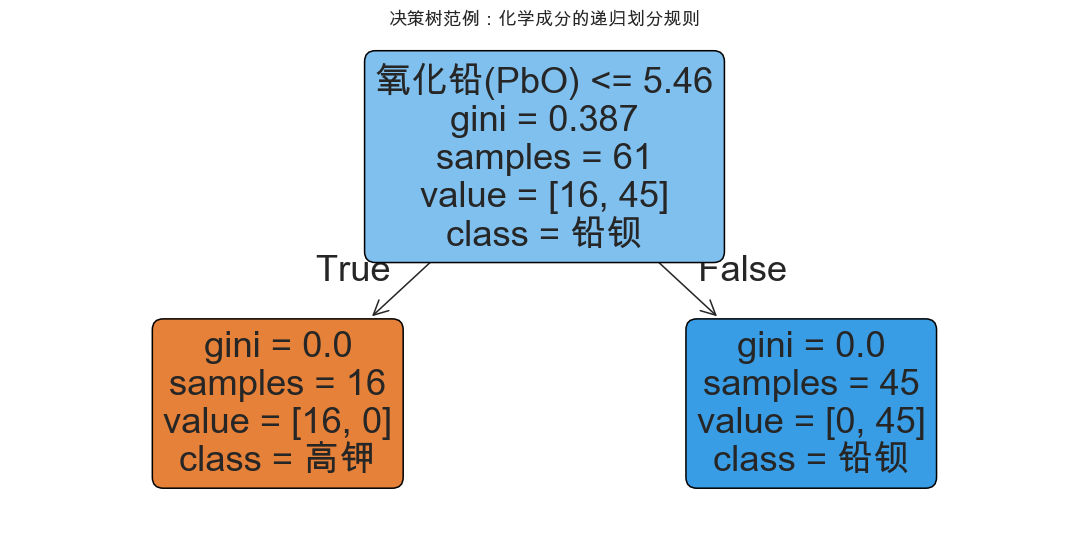

In [19]:
example_tree = DecisionTreeClassifier(
    criterion="gini", max_depth=2, min_samples_leaf=3, random_state=7
).fit(X_example, y_example)

fig, ax = plt.subplots(figsize=(10, 5))
plot_tree(
    example_tree, feature_names=EXAMPLE_FEATURES,
    class_names=["高钾", "铅钡"], filled=True, rounded=True, ax=ax,
)
ax.set_title("决策树范例：化学成分的递归划分规则")
plt.tight_layout()
plt.show()

### 练习6：用受约束决策树预测未知玻璃

使用 Gini、不超过指定深度的树直接预测，不进行标准化。

In [20]:
# UNQ_C6（不要修改下面两行注释，否则测试套件无法收集该函数）
# GRADED FUNCTION: predict_unknown_tree
def predict_unknown_tree(
    X, y, X_unknown, unknown_ids,
    max_depth=3, min_samples_leaf=2, random_state=42,
):
    '''训练决策树并预测未知玻璃类型。'''
    # 你的代码从这里开始
    # 第1步：建立使用Gini的决策树。
    model = ...

    # 第2步：拟合并预测未知样品。
    ...
    predictions = ...

    # 第3步：整理结果表。
    prediction_table = ...

    result = {
        "model": model,
        "predictions": predictions,
        "prediction_table": prediction_table,
    }
    # 你的代码到这里结束
    return result

In [ ]:
testsuite.test_predict_unknown_tree(predict_unknown_tree)

## 7. 随机森林

随机森林通过两层随机性训练多棵树：

1. 每棵树使用一份 bootstrap 有放回样本；
2. 每次分裂只查看随机抽取的一部分特征。

多棵不完全相关的树投票，通常比单棵树稳定。`feature_importances_` 汇总特征带来的不纯度下降，可帮助描述分类规律，但不能解释为因果效应。

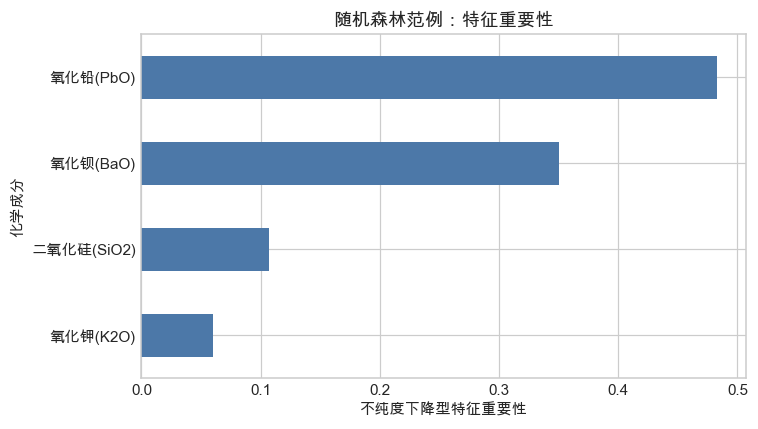

In [22]:
example_forest = RandomForestClassifier(
    n_estimators=80, max_depth=3, min_samples_leaf=2,
    max_features="sqrt", random_state=7, n_jobs=1,
).fit(X_example, y_example)

example_importance = pd.Series(
    example_forest.feature_importances_, index=EXAMPLE_FEATURES
).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
example_importance.plot.barh(ax=ax, color="#4C78A8")
ax.set_xlabel("不纯度下降型特征重要性")
ax.set_ylabel("化学成分")
ax.set_title("随机森林范例：特征重要性")
plt.tight_layout()
plt.show()

### 练习7：用随机森林预测未知玻璃

使用 120 棵树和六个正式特征，返回类别、铅钡概率及降序特征重要性。

In [23]:
# UNQ_C7（不要修改下面两行注释，否则测试套件无法收集该函数）
# GRADED FUNCTION: predict_unknown_forest
def predict_unknown_forest(
    X, y, X_unknown, unknown_ids,
    n_estimators=120, max_depth=4, random_state=42,
):
    '''训练随机森林并预测未知玻璃类型。'''
    # 你的代码从这里开始
    # 第1步：建立随机森林；固定min_samples_leaf=1、max_features="sqrt"、n_jobs=1。
    model = ...

    # 第2步：拟合并预测类别、概率。
    ...
    predictions = ...
    probabilities = ...

    # 第3步：整理降序特征重要性，Series名称为importance。
    feature_importance = ...

    # 第4步：整理预测表。
    prediction_table = ...

    result = {
        "model": model,
        "predictions": predictions,
        "probabilities": probabilities,
        "feature_importance": feature_importance,
        "prediction_table": prediction_table,
    }
    # 你的代码到这里结束
    return result

In [ ]:
testsuite.test_predict_unknown_forest(predict_unknown_forest)

## 8. K-means 玻璃亚型

亚类没有现成标签，因此应在高钾或铅钡大类内部做无监督聚类。K-means 最小化簇内平方和：

$$\sum_{k=1}^{K}\sum_{x_i\in C_k}\|x_i-\mu_k\|^2.$$

算法交替执行“分配到最近中心”和“重新计算中心”。由于初始中心随机，使用 `n_init=20` 重复初始化。聚类前标准化，聚类后把中心还原到原始百分含量，才能解释亚类的成分特征。

,二氧化硅(SiO2),氧化钾(K2O),氧化钙(CaO),氧化铝(Al2O3)
亚类,,,,
1,65.19,10.78,6.58,6.85
2,89.99,1.58,1.24,2.60


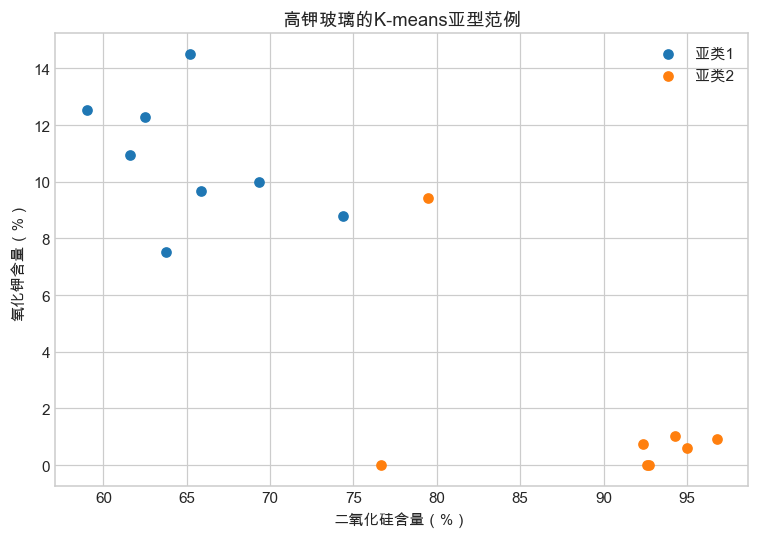

In [25]:
HIGH_K_FEATURES = [
    "二氧化硅(SiO2)", "氧化钾(K2O)",
    "氧化钙(CaO)", "氧化铝(Al2O3)",
]
high_k_example = known_data.loc[
    known_data["类型"] == "高钾",
    ["文物编号", "采样面状态", *HIGH_K_FEATURES],
].reset_index(drop=True)

high_k_scaler = StandardScaler().fit(high_k_example[HIGH_K_FEATURES])
high_k_scaled = high_k_scaler.transform(high_k_example[HIGH_K_FEATURES])
high_k_model = KMeans(n_clusters=2, n_init=30, random_state=7).fit(high_k_scaled)
high_k_example["亚类"] = high_k_model.labels_ + 1

high_k_centers = pd.DataFrame(
    high_k_scaler.inverse_transform(high_k_model.cluster_centers_),
    columns=HIGH_K_FEATURES, index=pd.Index([1, 2], name="亚类"),
)
display(high_k_centers.round(2))

fig, ax = plt.subplots(figsize=(7, 5))
for subtype, group in high_k_example.groupby("亚类"):
    ax.scatter(group["二氧化硅(SiO2)"], group["氧化钾(K2O)"], label=f"亚类{subtype}")
ax.set_xlabel("二氧化硅含量（%）")
ax.set_ylabel("氧化钾含量（%）")
ax.set_title("高钾玻璃的K-means亚型范例")
ax.legend()
plt.tight_layout()
plt.show()

### 练习8：划分铅钡玻璃亚型

练习使用 SiO₂、PbO、BaO、P₂O₅，与高钾范例的成分不同。

In [26]:
# UNQ_C8（不要修改下面两行注释，否则测试套件无法收集该函数）
# GRADED FUNCTION: cluster_glass_subtypes
def cluster_glass_subtypes(
    data, glass_type, feature_columns, n_clusters=2, random_state=42,
):
    '''在指定玻璃大类内部使用K-means划分亚型。'''
    # 你的代码从这里开始
    # 第1步：筛选玻璃大类，保留编号、状态及成分，删除成分缺失行。
    subset = ...
    subset = ...

    # 第2步：标准化成分。
    scaler = ...
    scaled_values = ...

    # 第3步：使用n_init=20拟合K-means。
    model = ...
    cluster_labels = ...

    # 第4步：亚类编号从1开始。
    assignments = ...

    # 第5步：将簇中心还原到原始百分含量，索引命名为亚类。
    centers = ...

    result = {
        "scaler": scaler,
        "model": model,
        "assignments": assignments,
        "centers": centers,
    }
    # 你的代码到这里结束
    return result

In [ ]:
testsuite.test_cluster_glass_subtypes(cluster_glass_subtypes)

## 9. 敏感性分析

敏感性分析不是再寻找一个最高分模型，而是改变合理条件，检查结论是否容易翻转。本章分别检查亚类聚类和未知玻璃预测。

### 9.1 K-means 的随机初始化敏感性

直接比较簇标签会遇到“标签交换”：一次运行的亚类1可能对应另一次的亚类2。应比较任意两个样品是否仍被放在同一簇，这与标签编号无关。

以第一次运行作为基准，对每个随机种子计算：

- `inertia`：簇内平方和；
- `pair_agreement`：所有样品对的“同簇/不同簇关系”与基准一致的比例。

比例越接近 1，结果越稳定。这只检查初始化，正式论文还应改变 K、特征组合和标准化方式。

In [28]:
base_seed_model = KMeans(n_clusters=2, n_init=20, random_state=1).fit(high_k_scaled)
base_same = base_seed_model.labels_[:, None] == base_seed_model.labels_[None, :]
upper_pairs = np.triu_indices(len(high_k_scaled), k=1)

seed_rows = []
for seed in [1, 7, 21, 42]:
    seed_model = KMeans(n_clusters=2, n_init=20, random_state=seed).fit(high_k_scaled)
    current_same = seed_model.labels_[:, None] == seed_model.labels_[None, :]
    seed_rows.append({
        "random_state": seed,
        "inertia": seed_model.inertia_,
        "pair_agreement": np.mean(current_same[upper_pairs] == base_same[upper_pairs]),
    })

display(pd.DataFrame(seed_rows).round(4))

,random_state,inertia,pair_agreement
0,1,18.4821,1.0
1,7,18.4821,1.0
2,21,18.4821,1.0
3,42,18.4821,1.0


### 练习9：计算 K-means 初始化敏感性

补全函数，用第一项种子作为基准，依次返回每次运行的簇内平方和和样品对一致率。

In [29]:
# UNQ_C9（不要修改下面两行注释，否则测试套件无法收集该函数）
# GRADED FUNCTION: analyze_kmeans_seed_sensitivity
def analyze_kmeans_seed_sensitivity(X_scaled, seeds, n_clusters=2):
    '''比较不同随机初始化下K-means的样品对关系。'''
    # 你的代码从这里开始
    # 第1步：用第一个种子拟合基准模型，并建立同簇关系矩阵。
    base_model = ...
    base_same = ...

    # 第2步：只取矩阵上三角，避免重复样品对和对角线。
    upper_pairs = ...

    # 第3步：依次拟合每个种子，计算inertia和pair_agreement。
    rows = []
    for seed in seeds:
        model = ...
        current_same = ...
        pair_agreement = ...
        rows.append({
            "random_state": seed,
            "inertia": ...,
            "pair_agreement": pair_agreement,
        })

    result = ...
    # 你的代码到这里结束
    return result

In [ ]:
testsuite.test_analyze_kmeans_seed_sensitivity(analyze_kmeans_seed_sensitivity)

### 9.2 未知玻璃的成分扰动敏感性

设某项含量的相对扰动标准差为 3%，重复生成：

$$x^*=\max(0,\ x(1+\varepsilon)),\qquad \varepsilon\sim N(0,0.03^2).$$

每次只改变未知样品，训练好的模型保持不变。对每件文物报告：

- 保持基准类别的比例；
- 被预测为铅钡的比例；
- 平均铅钡概率和概率标准差。

这是一种教学性的测量扰动分析，不是置信区间。若实验给出了真实测量误差，应使用真实误差范围替代 3%。

In [31]:
example_sensitivity_model = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2, svd_solver="full")),
    ("classifier", LogisticRegression(
        C=0.5, max_iter=1500, solver="liblinear", random_state=7
    )),
]).fit(X_example, y_example)

rng = np.random.default_rng(7)
base_prediction = example_sensitivity_model.predict(X_unknown_example)
repeat_predictions = []
repeat_probabilities = []

for _ in range(100):
    changed_values = pd.DataFrame(
        np.clip(
            X_unknown_example.to_numpy()
            * rng.normal(1.0, 0.03, X_unknown_example.shape),
            0,
            None,
        ),
        index=X_unknown_example.index,
        columns=X_unknown_example.columns,
    )
    repeat_predictions.append(example_sensitivity_model.predict(changed_values))
    repeat_probabilities.append(example_sensitivity_model.predict_proba(changed_values)[:, 1])

repeat_predictions = np.asarray(repeat_predictions)
repeat_probabilities = np.asarray(repeat_probabilities)
display(pd.DataFrame({
    "文物编号": unknown_ids_example,
    "基准预测": pd.Series(base_prediction).map(CODE_TO_TYPE),
    "保持基准类别比例": (repeat_predictions == base_prediction).mean(axis=0),
    "铅钡预测比例": (repeat_predictions == 1).mean(axis=0),
    "平均铅钡概率": repeat_probabilities.mean(axis=0),
    "概率标准差": repeat_probabilities.std(axis=0),
}).round(4))

,文物编号,基准预测,保持基准类别比例,铅钡预测比例,平均铅钡概率,概率标准差
0,A1,高钾,1.0,0.0,0.3399,0.0151
1,A2,铅钡,1.0,1.0,0.9058,0.0051
2,A3,铅钡,1.0,1.0,0.9322,0.0036
3,A4,铅钡,1.0,1.0,0.8959,0.0044
4,A5,铅钡,1.0,1.0,0.5983,0.0166
5,A6,高钾,1.0,0.0,0.1840,0.0125
6,A7,高钾,1.0,0.0,0.2100,0.0135
7,A8,铅钡,1.0,1.0,0.8667,0.0066


### 练习10：分析未知玻璃预测对成分扰动的敏感性

补全函数。传入的模型已经拟合完成，本题不重新训练模型，只重复扰动未知数据并汇总稳定性。

In [32]:
# UNQ_C10（不要修改下面两行注释，否则测试套件无法收集该函数）
# GRADED FUNCTION: analyze_prediction_sensitivity
def analyze_prediction_sensitivity(
    fitted_model, X_unknown, unknown_ids,
    relative_sd=0.03, repeats=100, random_state=42,
):
    '''通过相对扰动评估未知样品预测稳定性。'''
    # 你的代码从这里开始
    # 第1步：计算未扰动数据的基准预测。
    baseline = ...

    # 第2步：创建随机数生成器，重复扰动并保存类别和概率。
    # 扰动后恢复为与X_unknown索引、列名相同的DataFrame。
    rng = ...
    all_predictions = []
    all_probabilities = []
    for _ in range(repeats):
        changed_values = ...
        all_predictions.append(...)
        all_probabilities.append(...)

    # 第3步：转换为“重复次数 × 未知样品数”的数组。
    all_predictions = ...
    all_probabilities = ...

    # 第4步：逐件文物汇总稳定比例和概率波动。
    result = ...
    # 你的代码到这里结束
    return result

In [ ]:
testsuite.test_analyze_prediction_sensitivity(analyze_prediction_sensitivity)

## 10. 模型评价

### 10.1 为什么不能用训练数据评价

模型在训练样本上的成绩通常过于乐观。评价时应先分层划分训练集和测试集：测试集不参与 scaler、PCA 和分类器的拟合。

### 10.2 混淆矩阵

固定标签顺序 `[0, 1]` 后：

$$\begin{bmatrix}TN&FP\\FN&TP\end{bmatrix}.$$

本章以铅钡为正类 1。常用指标为：

$$Accuracy=\frac{TP+TN}{TP+TN+FP+FN},$$

$$Precision=\frac{TP}{TP+FP},\quad Recall=\frac{TP}{TP+FN},$$

$$Specificity=\frac{TN}{TN+FP},$$

$$F1=\frac{2TP}{2TP+FP+FN},$$

$$Balanced\ Accuracy=\frac{Recall+Specificity}{2}.$$

准确率回答总体正确多少；召回率回答多少铅钡被识别；特异度回答多少高钾被识别。类别不均衡时，应同时查看混淆矩阵和平衡准确率。

,数值
accuracy,1.0
precision,1.0
recall,1.0
specificity,1.0
f1,1.0
balanced_accuracy,1.0


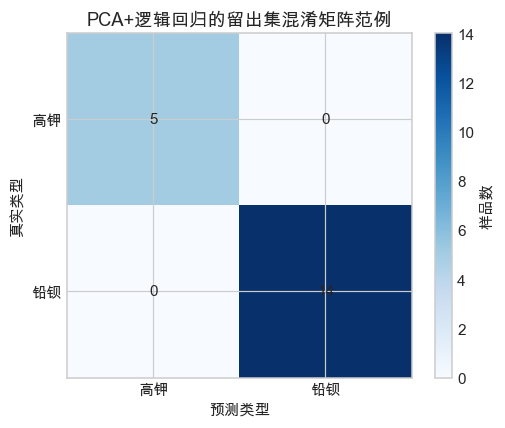

In [34]:
(X_train_eval, X_test_eval,
 y_train_eval, y_test_eval) = train_test_split(
    X_example, y_example, test_size=0.30,
    random_state=11, stratify=y_example,
)

evaluation_model = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2, svd_solver="full")),
    ("classifier", LogisticRegression(
        C=0.7, max_iter=1500, solver="liblinear", random_state=11
    )),
]).fit(X_train_eval, y_train_eval)

evaluation_prediction = evaluation_model.predict(X_test_eval)
evaluation_matrix = confusion_matrix(y_test_eval, evaluation_prediction, labels=[0, 1])
tn, fp, fn, tp = evaluation_matrix.ravel()

def safe_ratio(numerator, denominator):
    return numerator / denominator if denominator else 0.0

evaluation_metrics = pd.Series({
    "accuracy": safe_ratio(tp + tn, evaluation_matrix.sum()),
    "precision": safe_ratio(tp, tp + fp),
    "recall": safe_ratio(tp, tp + fn),
    "specificity": safe_ratio(tn, tn + fp),
    "f1": safe_ratio(2 * tp, 2 * tp + fp + fn),
    "balanced_accuracy": (
        safe_ratio(tp, tp + fn) + safe_ratio(tn, tn + fp)
    ) / 2,
})
display(evaluation_metrics.round(4).to_frame("数值"))

fig, ax = plt.subplots(figsize=(5, 4))
image = ax.imshow(evaluation_matrix, cmap="Blues")
for row in range(2):
    for column in range(2):
        ax.text(column, row, evaluation_matrix[row, column], ha="center", va="center")
ax.set_xticks([0, 1], ["高钾", "铅钡"])
ax.set_yticks([0, 1], ["高钾", "铅钡"])
ax.set_xlabel("预测类型")
ax.set_ylabel("真实类型")
ax.set_title("PCA+逻辑回归的留出集混淆矩阵范例")
fig.colorbar(image, ax=ax, label="样品数")
plt.tight_layout()
plt.show()

### 练习11：由混淆矩阵计算分类指标

补全 `compute_binary_metrics`。分母为 0 时返回 0.0，避免除零。这个函数可以复用于逻辑回归、KNN、决策树和随机森林，不需要为每种模型重复编写指标代码。

In [35]:
# UNQ_C11（不要修改下面两行注释，否则测试套件无法收集该函数）
# GRADED FUNCTION: compute_binary_metrics
def compute_binary_metrics(y_true, y_pred):
    '''从0/1二分类混淆矩阵计算常用评价指标。'''
    # 你的代码从这里开始
    # 第1步：固定labels=[0, 1]，展开TN、FP、FN、TP。
    matrix = ...
    tn, fp, fn, tp = ...

    # 第2步：定义安全除法。
    def safe_divide(numerator, denominator):
        return ...

    # 第3步：计算六个指标。
    accuracy = ...
    precision = ...
    recall = ...
    specificity = ...
    f1 = ...
    balanced_accuracy = ...

    result = {
        "confusion_matrix": matrix,
        "tn": tn, "fp": fp, "fn": fn, "tp": tp,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "specificity": specificity,
        "f1": f1,
        "balanced_accuracy": balanced_accuracy,
    }
    # 你的代码到这里结束
    return result

In [ ]:
testsuite.test_compute_binary_metrics(compute_binary_metrics)

## Checks

1. 已知数据和未知数据是否使用相同特征顺序？
2. scaler、PCA 是否只在训练数据上拟合？
3. PCA 的解释方差、载荷和样本得分是否分清？
4. PCA 得分是否真正进入逻辑回归，而不只是画图？
5. 四个监督分类器是否都输出 A1～A8 的预测？
6. K-means 是否在每个玻璃大类内部单独运行？
7. 聚类敏感性比较是否避免直接比较可能交换的簇编号？
8. 未知数据扰动比例是否有实际依据，并明确它不是置信区间？
9. 模型评价是否来自训练时不可见的数据？
10. 是否同时报告混淆矩阵、类别指标和小样本局限？

In [ ]:
student_grade = testsuite.grade_all_tests(NOTEBOOK_FILE)
print(f"本章自动评分：{student_grade}/100")

## Next Steps

完成练习以后，可以把四个监督模型对 A1～A8 的结果整理成同一张表，但不要简单把“多数投票”当作最终答案。应优先检查：

1. 已知样本上的分层验证成绩；
2. PCA+逻辑回归与其他模型是否一致；
3. 未知样品概率是否接近 0.5；
4. 成分扰动后类别是否频繁翻转；
5. K-means 在不同 K、特征组合和随机种子下是否保持主要亚类结构。

## 生成pdf报告

In [ ]:
import importlib
from IPython import get_ipython

# 获取项目根目录
project_root = Path().resolve().parent
sys.path.append(str(project_root / 'tests'))
sys.path.append(str(project_root / 'util'))

import notebook2pdf
importlib.reload(notebook2pdf)

ip = get_ipython()
notebook_file = None
if '__vsc_ipynb_file__' in ip.user_ns:
    notebook_file = ip.user_ns['__vsc_ipynb_file__']

pdf_file = f"2022c-03-机器学习模型.pdf"
notebook2pdf.convert_notebook_to_webpdf(notebook_file, pdf_file)

Notebook to PDF: 100%|██████████| 100/100 [00:04<00:00, 20.38%/s]



成功生成报告文件: 2022c-01-数据预处理.pdf
